# MRI dataset exploration with DeepInverse

This notebook uses [DeepInverse](https://deepinv.github.io) as the main library to:
1. Load FastMRI slices via `deepinv.datasets.SimpleFastMRISliceDataset`
2. Explore the data (k-space, magnitude, real/imaginary)
3. Apply MRI forward physics (`deepinv.physics.MRI`) with different undersampling masks
4. Compare against the project's own `HDF5Dataset` loader from `utils/dataset.py`

In [1]:
import sys
import os

import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader

PROJECT_ROOT = os.path.abspath('..')
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

import deepinv as dinv
from deepinv.datasets import SimpleFastMRISliceDataset
from deepinv.physics import MRI
from deepinv.physics.generator import GaussianMaskGenerator, EquispacedMaskGenerator, RandomMaskGenerator
from deepinv.utils import get_data_home

from utils.dataset import HDF5Dataset

%matplotlib inline

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'deepinv {dinv.__version__}  |  device: {device}')

/Users/raphael/Workspace/epfl/code/DeadLeavesPlus/.venv/lib/python3.14/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


deepinv 0.4.0  |  device: cpu


## 1. Load the FastMRI dataset

`SimpleFastMRISliceDataset` downloads a small prebuilt subset (2 knee + 2 brain slices) so no manual data agreement is needed for the demo. Images are complex-valued with shape `(2, H, W)` — channel 0 is the real part, channel 1 the imaginary part.

In [2]:
DATA_ROOT = get_data_home()
ANATOMY   = 'knee'   # 'knee' or 'brain'

dataset = SimpleFastMRISliceDataset(
    root_dir=DATA_ROOT,
    anatomy=ANATOMY,
    download=True,
    train=True,
)
print(f'Dataset size : {len(dataset)} slices')
print(f'Sample shape : {dataset[0].shape}  (channels=2 → real, imaginary)')

100%|██████████| 801k/801k [00:00<00:00, 6.59MB/s]

Dataset size : 2 slices
Sample shape : torch.Size([2, 320, 320])  (channels=2 → real, imaginary)


## 2. Explore the data

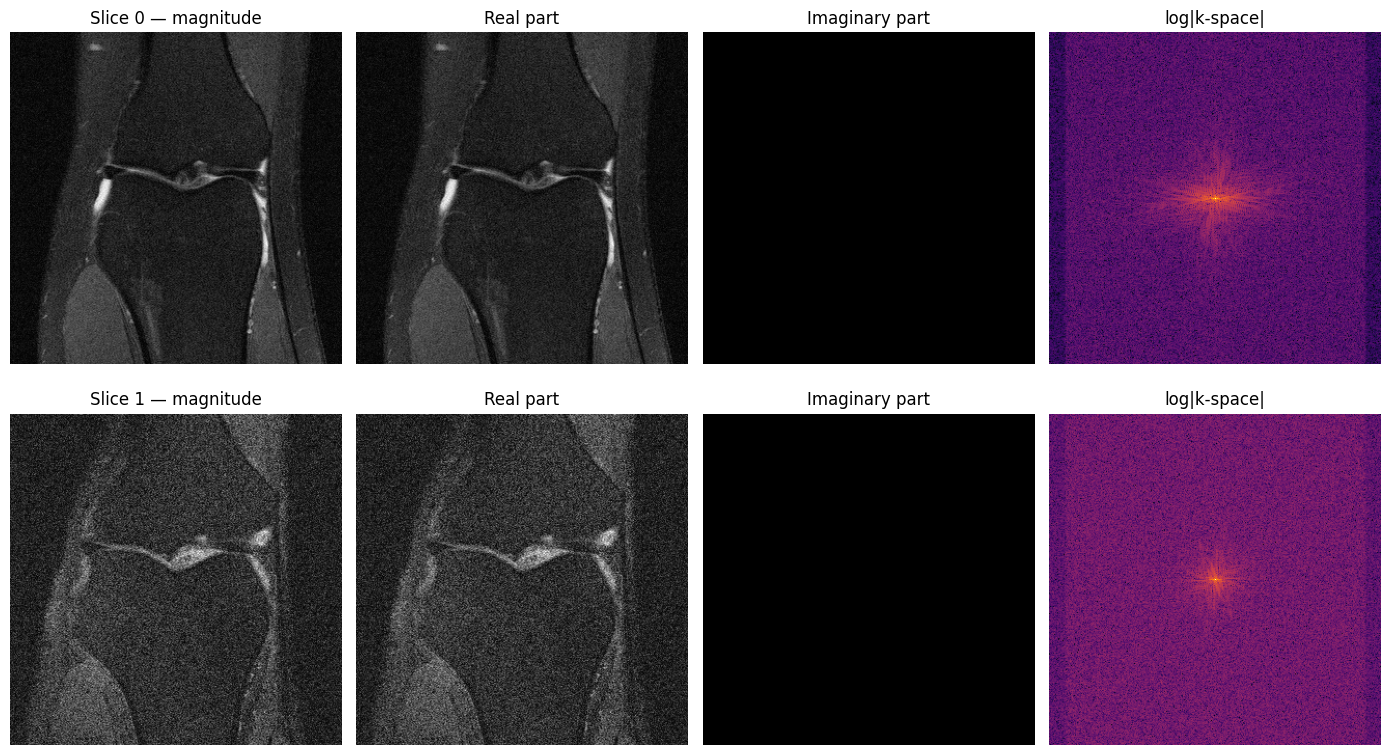

In [ ]:
def magnitude(x):
    """Complex magnitude from a (2, H, W) real/imag tensor."""
    return (x[0] ** 2 + x[1] ** 2).sqrt()


fig, axs = plt.subplots(len(dataset), 4, figsize=(14, 4 * len(dataset)))
if len(dataset) == 1:
    axs = axs[np.newaxis]\

for i, sample in enumerate(dataset):
    mag  = magnitude(sample).numpy()
    real = sample[0].numpy()
    imag = sample[1].numpy()

    # Log-magnitude k-space (Fourier of the image)
    kspace = torch.fft.fftshift(torch.fft.fft2(torch.complex(sample[0], sample[1])))
    log_kspace = torch.log1p(kspace.abs()).numpy()

    axs[i, 0].imshow(mag,         cmap='gray');  axs[i, 0].set_title(f'Slice {i} — magnitude')
    axs[i, 1].imshow(real,        cmap='gray');  axs[i, 1].set_title('Real part')
    axs[i, 2].imshow(imag,        cmap='gray');  axs[i, 2].set_title('Imaginary part')
    axs[i, 3].imshow(log_kspace,  cmap='inferno'); axs[i, 3].set_title('log|k-space|')

    for ax in axs[i]:
        ax.axis('off')

plt.tight_layout()
plt.show()

In [4]:
# Basic statistics across the dataset
print(f'{'Slice':>6}  {'shape':>12}  {'min':>8}  {'max':>8}  {'mean':>8}  {'std':>8}')
print('-' * 60)
for i, sample in enumerate(dataset):
    mag = magnitude(sample)
    print(f'{i:>6}  {str(tuple(sample.shape)):>12}  {sample.min():>8.4f}  {sample.max():>8.4f}  {mag.mean():>8.4f}  {mag.std():>8.4f}')

 Slice         shape       min       max      mean       std
------------------------------------------------------------
     0  (2, 320, 320)    0.0000    1.0000    0.1401    0.0958
     1  (2, 320, 320)    0.0000    1.0000    0.1988    0.1125


## 3. MRI forward physics and undersampling masks

`deepinv.physics.MRI` implements the operator $y = MFx$ where $F$ is the 2-D Fourier transform and $M$ is a binary undersampling mask. We compare three mask strategies at the same acceleration factor.

In [5]:
# Pick one slice as the reference image
SLICE_IDX      = 0
ACCELERATION   = 4    # keep 1/4 of k-space lines

x = dataset[SLICE_IDX].unsqueeze(0).to(device)   # (1, 2, H, W)
C, H, W = x.shape[1], x.shape[2], x.shape[3]
img_size = (C, H, W)
print(f'Image shape: {tuple(x.shape)}')

Image shape: (1, 2, 320, 320)


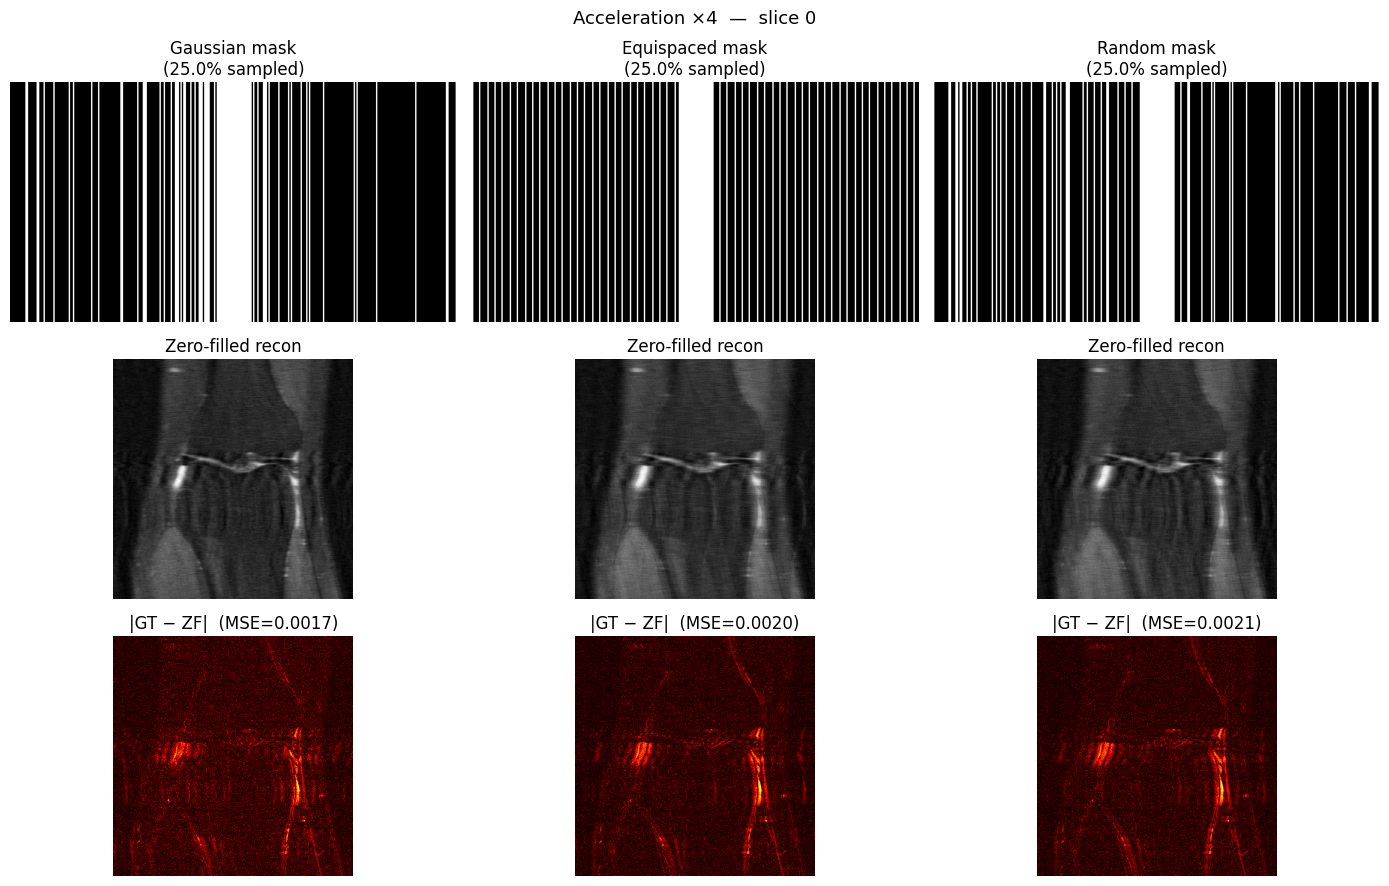

In [6]:
# Build three different masks at the same acceleration factor
mask_generators = {
    'Gaussian':   GaussianMaskGenerator(img_size=img_size, acceleration=ACCELERATION, device=device),
    'Equispaced': EquispacedMaskGenerator(img_size=img_size, acceleration=ACCELERATION, device=device),
    'Random':     RandomMaskGenerator(img_size=img_size, acceleration=ACCELERATION, device=device),
}

masks = {name: gen.step(batch_size=1)['mask'] for name, gen in mask_generators.items()}

# Visualise masks and the resulting zero-filled reconstructions
fig, axs = plt.subplots(3, len(masks), figsize=(14, 9))
fig.suptitle(f'Acceleration ×{ACCELERATION}  —  slice {SLICE_IDX}', fontsize=13)

for col, (name, mask) in enumerate(masks.items()):
    physics   = MRI(mask=mask, device=device)
    y         = physics(x)                     # undersampled k-space
    x_zf      = physics.A_adjoint(y)           # zero-filled reconstruction
    mag_zf    = magnitude(x_zf[0].cpu())
    mag_orig  = magnitude(x[0].cpu())

    # Mask (show which k-space columns are sampled)
    axs[0, col].imshow(mask[0, 0].cpu().numpy(), cmap='gray', aspect='auto')
    sampled_pct = mask.float().mean().item() * 100
    axs[0, col].set_title(f'{name} mask\n({sampled_pct:.1f}% sampled)')

    # Zero-filled reconstruction
    axs[1, col].imshow(mag_zf.numpy(), cmap='gray')
    axs[1, col].set_title('Zero-filled recon')

    # Difference from ground truth
    diff = (mag_orig - mag_zf).abs()
    axs[2, col].imshow(diff.numpy(), cmap='hot')
    axs[2, col].set_title(f'|GT − ZF|  (MSE={diff.pow(2).mean():.4f})')

    for row in range(3):
        axs[row, col].axis('off')

plt.tight_layout()
plt.show()

## 4. Effect of acceleration factor

Sweep over several acceleration factors with a Gaussian mask and measure the zero-filled PSNR.

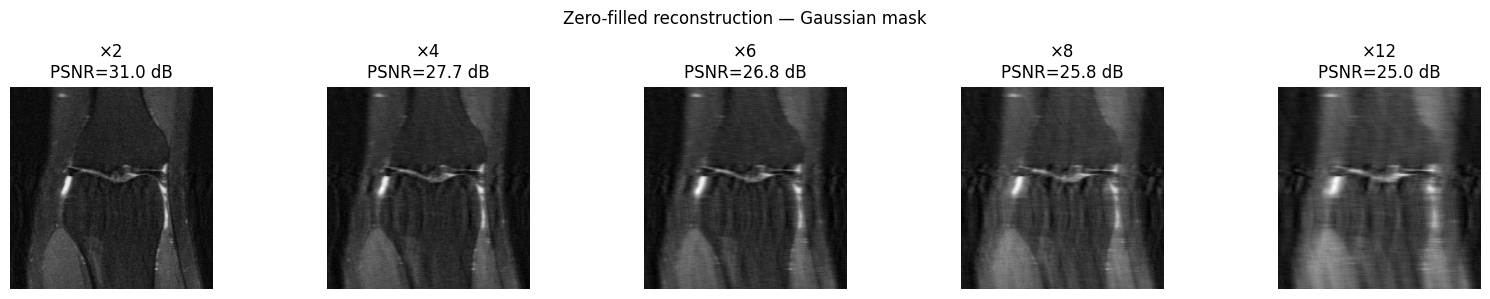

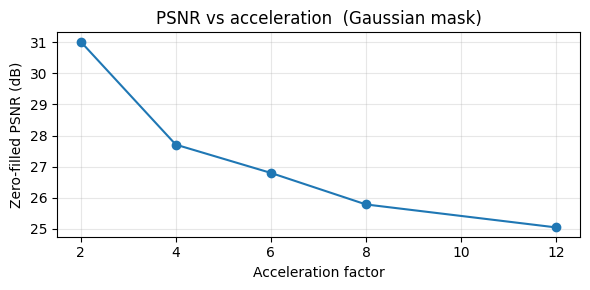

In [7]:
from skimage.metrics import peak_signal_noise_ratio as psnr_fn

accelerations = [2, 4, 6, 8, 12]
psnrs = []

mag_orig_np = magnitude(x[0].cpu()).numpy()
data_range  = mag_orig_np.max() - mag_orig_np.min()

fig, axs = plt.subplots(1, len(accelerations), figsize=(16, 3))
fig.suptitle('Zero-filled reconstruction — Gaussian mask', fontsize=12)

for col, acc in enumerate(accelerations):
    gen     = GaussianMaskGenerator(img_size=img_size, acceleration=acc, device=device)
    mask    = gen.step(batch_size=1)['mask']
    physics = MRI(mask=mask, device=device)
    x_zf    = physics.A_adjoint(physics(x))
    mag_zf  = magnitude(x_zf[0].cpu()).numpy()

    p = psnr_fn(mag_orig_np, mag_zf, data_range=data_range)
    psnrs.append(p)

    axs[col].imshow(mag_zf, cmap='gray')
    axs[col].set_title(f'×{acc}\nPSNR={p:.1f} dB')
    axs[col].axis('off')

plt.tight_layout()
plt.show()

fig2, ax2 = plt.subplots(figsize=(6, 3))
ax2.plot(accelerations, psnrs, '-o')
ax2.set_xlabel('Acceleration factor')
ax2.set_ylabel('Zero-filled PSNR (dB)')
ax2.set_title('PSNR vs acceleration  (Gaussian mask)')
ax2.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 5. DataLoader integration

Test that `SimpleFastMRISliceDataset` works correctly inside a `DataLoader`, and apply the MRI physics on-the-fly per batch.

In [ ]:
loader = DataLoader(dataset, batch_size=2, shuffle=False, num_workers=0)

# Gaussian mask generator reused across batches
mask_gen = GaussianMaskGenerator(img_size=img_size, acceleration=4, device=device)

print(f'{'Batch':>6}  {'x shape':>16}  {'y shape':>16}  {'ZF PSNR (dB)':>14}')
print('-' * 60)

for batch_idx, batch in enumerate(loader):
    x_batch = batch.to(device)              # (B, 2, H, W)
    B = x_batch.shape[0]

    mask    = mask_gen.step(batch_size=B)['mask']
    physics = MRI(mask=mask, device=device)
    y_batch = physics(x_batch)              # undersampled k-space
    zf      = physics.A_adjoint(y_batch)    # zero-filled

    # Per-sample PSNR on magnitude images
    psnr_vals = []
    for b in range(B):
        orig = magnitude(x_batch[b].cpu()).numpy()
        recon = magnitude(zf[b].cpu()).numpy()
        dr = orig.max() - orig.min()
        psnr_vals.append(psnr_fn(orig, recon, data_range=dr))

    print(f'{batch_idx:>6}  {str(tuple(x_batch.shape)):>16}  {str(tuple(y_batch.shape)):>16}  {np.mean(psnr_vals):>14.2f}')

## 6. Comparison with the project's `HDF5Dataset`

The project's `HDF5Dataset` (in `utils/dataset.py`) is a generic HDF5 loader. Here we show how to save a slice from the DeepInverse dataset into an HDF5 file and reload it via `HDF5Dataset`, so both dataloaders can be used interchangeably in training pipelines.

In [ ]:
import h5py
import tempfile

# Save all slices from the DeepInverse dataset into a single HDF5 file
tmp_dir  = tempfile.mkdtemp()
h5_path  = os.path.join(tmp_dir, 'mri_slices.h5')

with h5py.File(h5_path, 'w') as h5f:
    for i, sample in enumerate(dataset):
        # Store as (2, H, W) float32 — same convention as deepinv
        h5f.create_dataset(str(i), data=sample.numpy().astype(np.float32))

print(f'Saved {len(dataset)} slices to {h5_path}')

# Reload with the project's HDF5Dataset
h5_dataset = HDF5Dataset(file_path=tmp_dir, recursive=False, load_data=True)
print(f'HDF5Dataset length : {len(h5_dataset)}')
print(f'HDF5Dataset sample shape: {h5_dataset[0].shape}')

In [ ]:
# Sanity-check: the two loaders return the same data
for i in range(len(dataset)):
    dinv_sample = dataset[i]            # torch.Tensor (2, H, W)
    h5_sample   = h5_dataset[i]        # torch.Tensor (2, H, W)
    max_diff = (dinv_sample - h5_sample).abs().max().item()
    print(f'Slice {i}  |  max |dinv − h5| = {max_diff:.2e}  ✓' if max_diff < 1e-5 else f'Slice {i}  |  MISMATCH: {max_diff:.2e}')

In [ ]:
# Side-by-side magnitude comparison from both loaders
fig, axs = plt.subplots(2, len(dataset), figsize=(5 * len(dataset), 8))
if len(dataset) == 1:
    axs = axs[:, np.newaxis]

for i in range(len(dataset)):
    axs[0, i].imshow(magnitude(dataset[i]).numpy(),   cmap='gray')
    axs[0, i].set_title(f'SimpleFastMRI [{i}]')
    axs[1, i].imshow(magnitude(h5_dataset[i]).numpy(), cmap='gray')
    axs[1, i].set_title(f'HDF5Dataset [{i}]')
    for row in range(2):
        axs[row, i].axis('off')

fig.suptitle('deepinv vs HDF5Dataset — magnitude images', fontsize=12)
plt.tight_layout()
plt.show()

## 7. Physics consistency check: A and A*

Verify that the `MRI` operator satisfies $\langle Ax, y \rangle = \langle x, A^*y \rangle$ (adjoint test) and that the pseudo-inverse gives back the original image on fully-sampled data.

In [ ]:
torch.manual_seed(0)
physics_full = MRI(img_size=x.shape, device=device)   # full sampling (no mask)

# Adjoint test
u = torch.randn_like(x)
v = torch.randn_like(physics_full(x))
lhs = (physics_full(u) * v).sum().item()
rhs = (u * physics_full.A_adjoint(v)).sum().item()
print(f'Adjoint test  <Au, v> = {lhs:.6f}  |  <u, A*v> = {rhs:.6f}  |  rel. error = {abs(lhs-rhs)/abs(lhs):.2e}')

# Full reconstruction: A* A x should equal x when mask = 1
recon = physics_full.A_adjoint(physics_full(x))
rel_err = (recon - x).norm() / x.norm()
print(f'Full-sampling recon error (||A*Ax - x|| / ||x||) = {rel_err.item():.2e}')